# A Theory of Fads, Fashion, Custom, and Structural Change as Informational Cascades (BHW, 1992)
**Goal:** replicate key theoretical results (Fig. 1, Table 2, Result 4) and provide **extra outcomes** on real market data (BTC + Russell 3000) as a stylized empirical analogue.

**Key idea (BHW):** sequential decisions + private signals + observing *actions* ⇒ informational cascades that are **common**, can be **wrong**, and are **fragile** to new public information.



## 0. Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


---
## 1. Core simulator (binary PAO) + rare public signals
We simulate the binary model from BHW (Section II.A) in the **PAO** regime (agents observe past **actions**).  
State variable `diff` is interpreted as an **inferred** net count of (H − L) signals. A cascade corresponds to `|diff| ≥ 2`.

**Important:** once a cascade forms, *actions stop aggregating information* (they are uninformative), so `diff` is updated only by **public signals** (Section III).


In [ ]:
def simulate_bhw_diff(
    n_agents:int,
    p:float,
    q_public:float=0.0,
    true_value:int=1,
    n_sims:int=5000,
    seed:int=42
):
    rng = np.random.default_rng(seed)
    diff = np.zeros(n_sims, dtype=np.int16)

    pH = p if true_value == 1 else (1 - p)

    for _ in range(n_agents):
        if q_public > 0:
            pub_arrive = rng.random(n_sims) < q_public
            pub_sig = np.where(rng.random(n_sims) < pH, 1, -1).astype(np.int16)
            diff += (pub_arrive.astype(np.int16) * pub_sig)

        in_cascade = (np.abs(diff) >= 2)

        not_cascade = ~in_cascade
        if not_cascade.any():
            sig = np.where(rng.random(n_sims) < pH, 1, -1).astype(np.int16)
            w = diff + sig

            action = np.sign(w).astype(np.int16)

            ties = (w == 0)
            if ties.any():
                flip = np.where(rng.random(ties.sum()) < 0.5, 1, -1).astype(np.int16)
                action[ties] = flip

            diff[not_cascade] += action[not_cascade]

    p_up = np.mean(diff >= 2)
    p_down = np.mean(diff <= -2)
    exp_diff = float(np.mean(diff))

    return p_up, p_down, exp_diff, diff


---
## 2. Replication: Figure 1 (Probability of correct vs incorrect cascades)
We fix `V=1` so that an **UP** cascade is “correct” and a **DOWN** cascade is “incorrect”.  
For each `p`, we run Monte Carlo and estimate probabilities.

(Implementation note) We vary RNG seed across `p` to avoid reusing identical random streams for each grid point.


Running Monte-Carlo for Fig.1...


  0%|          | 0/20 [00:00<?, ?it/s]

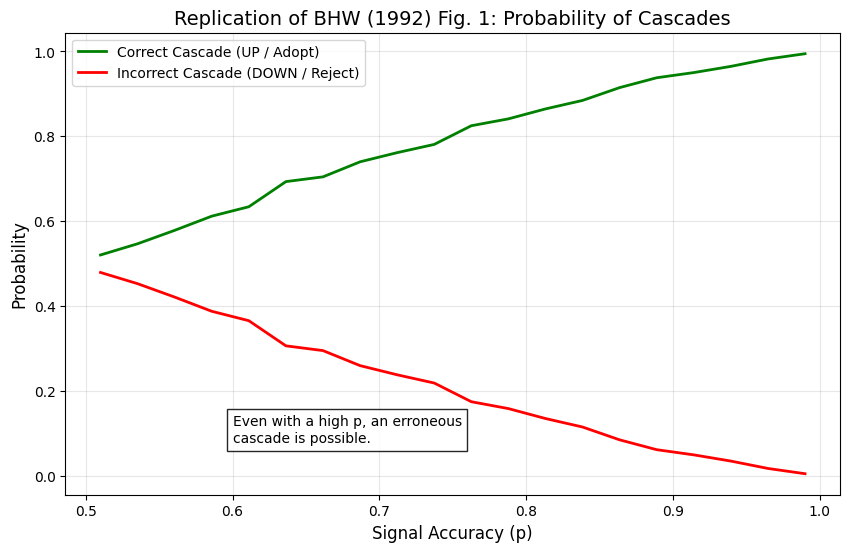

In [ ]:
p_values = np.linspace(0.51, 0.99, 20)

correct_probs = []
wrong_probs = []

print("Running Monte-Carlo for Fig.1...")
for i, p in enumerate(tqdm(p_values)):
    p_up, p_down, _, _ = simulate_bhw_diff(
        n_agents=100,
        p=float(p),
        q_public=0.0,
        true_value=1,
        n_sims=5000,
        seed=123 + i
    )
    correct_probs.append(p_up)
    wrong_probs.append(p_down)

plt.figure(figsize=(10,6))
plt.plot(p_values, correct_probs, color="green", lw=2, label="Correct Cascade (UP / Adopt)")
plt.plot(p_values, wrong_probs, color="red", lw=2, label="Incorrect Cascade (DOWN / Reject)")
plt.title("Replication of BHW (1992) Fig. 1: Probability of Cascades", fontsize=14)
plt.xlabel("Signal Accuracy (p)", fontsize=12)
plt.ylabel("Probability", fontsize=12)
plt.grid(alpha=0.3)
plt.legend()
plt.text(
    0.60, 0.08,
    "Even with a high p, an erroneous\ncascade is possible.",
    bbox=dict(facecolor='white', alpha=0.85)
)
plt.show()


---
## 3. Replication: Table 2 (Public information releases)
We replicate BHW Table 2 by allowing a **public signal** to arrive before each agent with probability:
- `q=0` (no public information),
- `q=1/1000` (≈ 1 public release per 1000 agents),
- `q=10/1000` (≈ 10 public releases per 1000 agents).

We report:
- `P(UP cascade @1000)`, `P(DOWN cascade @1000)`,
- `E[diff]` as a proxy for “expected inferred (H − L)” at i=1000.


In [ ]:
def replicate_table2(n_sims=10000, seed=42):
    p_list = [0.55, 0.65, 0.75, 0.85, 0.95]
    q_list = [0.0, 1/1000, 10/1000]
    q_names = {0.0:"No public", 1/1000:"Public(1/1000)", 10/1000:"Public(10/1000)"}

    rows = []
    for p in p_list:
        for q in q_list:
            p_up, p_down, exp_diff, _ = simulate_bhw_diff(
                n_agents=1000,
                p=p,
                q_public=q,
                true_value=1,
                n_sims=n_sims,
                seed=seed
            )
            rows.append({
                "p": p,
                "scenario": q_names[q],
                "P(UP cascade @1000)": p_up,
                "P(DOWN cascade @1000)": p_down,
                "E[diff] (≈ inferred H-L)": exp_diff
            })

    return pd.DataFrame(rows)

df_table2 = replicate_table2(n_sims=10000, seed=7)
display(df_table2)

pivot = df_table2.pivot(index="p", columns="scenario", values=["P(UP cascade @1000)", "P(DOWN cascade @1000)", "E[diff] (≈ inferred H-L)"])
display(pivot)


,p,scenario,P(UP cascade @1000),P(DOWN cascade @1000),E[diff] (≈ inferred H-L)
0,0.55,No public,0.5593,0.4407,0.2372
1,0.55,Public(1/1000),0.5774,0.4220,0.4221
2,0.55,Public(10/1000),0.6290,0.3702,1.4560
3,0.65,No public,0.6923,0.3077,0.7692
4,0.65,Public(1/1000),0.7203,0.2796,1.2132
5,0.65,Public(10/1000),0.8402,0.1594,4.2247
6,0.75,No public,0.8027,0.1973,1.2108
7,0.75,Public(1/1000),0.8344,0.1654,1.8651
8,0.75,Public(10/1000),0.9562,0.0435,6.7275
9,0.85,No public,0.8986,0.1014,1.5944


P(UP cascade @1000)                                 \
scenario           No public Public(1/1000) Public(10/1000)   
p                                                             
0.55                  0.5593         0.5774          0.6290   
0.65                  0.6923         0.7203          0.8402   
0.75                  0.8027         0.8344          0.9562   
0.85                  0.8986         0.9255          0.9911   
0.95                  0.9731         0.9817          0.9996   

         P(DOWN cascade @1000)                                 \
scenario             No public Public(1/1000) Public(10/1000)   
p                                                               
0.55                    0.4407         0.4220          0.3702   
0.65                    0.3077         0.2796          0.1594   
0.75                    0.1973         0.1654          0.0435   
0.85                    0.1014         0.0743          0.0089   
0.95                    0.0269         0.0183          0.0004   

         E[diff] (≈ inferred H-L)                                 
scenario                No public Public(1/1000) Public(10/1000)  
p                                                                 
0.55                       0.2372         0.4221          1.4560  
0.65                       0.7692         1.2132          4.2247  
0.75                       1.2108         1.8651          6.7275  
0.85                       1.5944         2.4266          8.8689  
0.95                       1.8924         2.8379         10.9774

---
## 4. Replication: Result 4 (Fads) — reversals can exceed fundamental change probability
We implement the “redraw” setup from Section V:
- up to i=100 the true value is `V`,
- at i=101 with probability `0.1` the value is redrawn, producing `W`,
- therefore `P(W≠V)=0.05`, but BHW show `P(cascade reversal) > 0.0935`.

We estimate `P(reversal)` and report a simple binomial CI.


In [ ]:
import math

def update_logodds(L, p, action, llr, tol=1e-12, eps=1e-15):

    def P_adopt_given_pH(pH):

        L_post_H = L + llr
        if L_post_H > tol: paH = 1.0
        elif L_post_H < -tol: paH = 0.0
        else: paH = 0.5

        L_post_L = L - llr
        if L_post_L > tol: paL = 1.0
        elif L_post_L < -tol: paL = 0.0
        else: paL = 0.5

        return pH*paH + (1-pH)*paL

    PA1 = P_adopt_given_pH(p)
    PA0 = P_adopt_given_pH(1-p)

    PA1 = min(max(PA1, eps), 1-eps)
    PA0 = min(max(PA0, eps), 1-eps)

    if action == 1:
        return L + math.log(PA1/PA0)
    else:
        return L + math.log((1-PA1)/(1-PA0))

def simulate_fads_once(p=0.9, redraw_prob=0.1, n_pre=100, n_post=10, seed=None, tol=1e-12):
    rng = np.random.default_rng(seed)
    llr = math.log(p/(1-p))

    V = 1 if rng.random() < 0.5 else 0
    L = 0.0

    def cascade_dir(L):
        if L > llr + tol: return 1
        if L < -llr - tol: return -1
        return 0

    for _ in range(n_pre):
        if L > llr + tol:
            action = 1
        elif L < -llr - tol:
            action = -1
        else:
            pH = p if V == 1 else (1-p)
            sig = 1 if rng.random() < pH else -1
            L_post = L + sig*llr
            if L_post > tol: action = 1
            elif L_post < -tol: action = -1
            else: action = 1 if rng.random() < 0.5 else -1

        L = update_logodds(L, p, action, llr, tol=tol)

    dir_pre = cascade_dir(L)

    W = V
    if rng.random() < redraw_prob:
        W = 1 if rng.random() < 0.5 else 0

    b = 1/(1+math.exp(-L))
    b = (1-redraw_prob)*b + redraw_prob*0.5
    L = math.log(b/(1-b))

    for _ in range(n_post):
        if L > llr + tol:
            action = 1
        elif L < -llr - tol:
            action = -1
        else:
            pH = p if W == 1 else (1-p)
            sig = 1 if rng.random() < pH else -1
            L_post = L + sig*llr
            if L_post > tol: action = 1
            elif L_post < -tol: action = -1
            else: action = 1 if rng.random() < 0.5 else -1

        L = update_logodds(L, p, action, llr, tol=tol)

    dir_post = cascade_dir(L)

    reversal = (dir_pre != 0 and dir_post != 0 and dir_pre == -dir_post)
    value_changed = (W != V)

    return reversal, value_changed

def replicate_result4(n_sims=20000, seed=0):
    rng = np.random.default_rng(seed)
    rev = 0
    chg = 0

    for _ in tqdm(range(n_sims)):
        r, c = simulate_fads_once(seed=int(rng.integers(0, 2**31-1)))
        rev += r
        chg += c

    return rev/n_sims, chg/n_sims

p_rev, p_change = replicate_result4(n_sims=20000, seed=1)
print("Estimated P(cascade reversal) =", p_rev)
print("Estimated P(value actually changes) =", p_change, " (should be ≈ 0.05)")


def binom_ci(p_hat, n, z=1.96):
    se = np.sqrt(p_hat*(1-p_hat)/n)
    return (p_hat - z*se, p_hat + z*se)

p_rev, p_change = replicate_result4(n_sims=20000, seed=1)
ci_rev = binom_ci(p_rev, 20000)
ci_chg = binom_ci(p_change, 20000)

print(f"Estimated P(cascade reversal) = {p_rev:.4f}  (95% CI: [{ci_rev[0]:.4f}, {ci_rev[1]:.4f}])")
print(f"Estimated P(value changes)    = {p_change:.4f}  (95% CI: [{ci_chg[0]:.4f}, {ci_chg[1]:.4f}])  (target ≈ 0.05)")
print("BHW claim (Result 4): P(reversal) > 0.0935 while P(value changes)=0.05")


  0%|          | 0/20000 [00:00<?, ?it/s]

Estimated P(cascade reversal) = 0.10095
Estimated P(value actually changes) = 0.04885  (should be ≈ 0.05)


  0%|          | 0/20000 [00:00<?, ?it/s]

Estimated P(cascade reversal) = 0.1009  (95% CI: [0.0968, 0.1051])
Estimated P(value changes)    = 0.0488  (95% CI: [0.0459, 0.0518])  (target ≈ 0.05)
BHW claim (Result 4): P(reversal) > 0.0935 while P(value changes)=0.05


---
## 5. Extra outcomes: Market analogue (BTC + Russell 3000)
**Caveat:** BHW is about *sequential individual actions*. In markets we do not observe those actions directly, so we use a **stylized analogue**:
- proxy “action” = sign of return (Up/Down),
- cascade-like persistence ⇒ unusually **few** runs (Z < 0),
- fragility / frequent information arrival ⇒ unusually **many** runs (Z > 0).

We then test this on a large cross-section (Russell 3000).


In [ ]:
DATA_PATH = "/content/drive/MyDrive/datasets/top3000_data_df.parquet"
CAPS_PATH = "/content/drive/MyDrive/datasets/top3000_market_caps.parquet"


### 5.1 Runs test implementation (stable) + wide-matrix runner
We explicitly set `fill_method=None` in `pct_change` (avoid deprecation + unintended padding).


In [ ]:
import numpy as np
import pandas as pd

def runs_test_z(signs: np.ndarray):
    signs = signs.astype(float)
    signs = signs[~np.isnan(signs)]
    signs = signs[signs != 0]
    n = len(signs)
    if n < 2:
        return np.nan, n, np.nan, np.nan, np.nan

    n1 = int(np.sum(signs == 1))
    n2 = int(np.sum(signs == -1))
    if n1 == 0 or n2 == 0:
        return np.nan, n, np.nan, n1, n2

    runs = int(1 + np.sum(signs[1:] != signs[:-1]))
    ER = 1.0 + (2.0 * n1 * n2) / (n1 + n2)
    VarR = (2.0*n1*n2*(2.0*n1*n2 - n1 - n2)) / (((n1+n2)**2) * (n1+n2 - 1))
    if not np.isfinite(VarR) or VarR <= 0:
        return np.nan, n, runs, n1, n2
    Z = (runs - ER) / np.sqrt(VarR)
    return float(Z), n, runs, n1, n2

def compute_russell_runs_wide(price_df: pd.DataFrame, min_obs=200, freq=None, max_tickers=None):
    df = price_df.copy()
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    if max_tickers is not None:
        df = df.iloc[:, :max_tickers]
    if freq is not None:
        df = df.resample(freq).last()

    rets = df.pct_change(fill_method=None)
    signs = np.sign(rets.to_numpy(dtype=float))
    cols = df.columns.to_list()

    out = []
    for j, col in enumerate(cols):
        s = signs[:, j]
        z, n, runs, n1, n2 = runs_test_z(s)
        if np.isnan(z) or n < min_obs:
            continue
        vol = float(np.nanstd(rets[col].to_numpy(dtype=float)))
        if not np.isfinite(vol):
            continue
        out.append({
            "ticker": col,
            "n_obs": int(n),
            "z_runs": float(z),
            "volatility": vol
        })
    return pd.DataFrame(out)


In [ ]:
import os, glob
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount failed / not in Colab:", e)

CANDIDATES = [
    "/content/drive/MyDrive/datasets/top3000_data_df.parquet",
    "/content/drive/MyDrive/Datasets/top3000_data_df.parquet",
]

DATA_PATH = None
for p in CANDIDATES:
    if os.path.exists(p):
        DATA_PATH = p
        break

if DATA_PATH is None:
    root = Path("/content/drive/MyDrive")
    if root.exists():
        matches = list(root.rglob("top3000_data_df.parquet"))
        if matches:
            DATA_PATH = str(matches[0])

print("Resolved DATA_PATH:", DATA_PATH)

if DATA_PATH is None:
    print("\nListing /content/drive:", os.listdir("/content/drive") if os.path.exists("/content/drive") else "NO /content/drive")
    if os.path.exists("/content/drive/MyDrive"):
        print("\nListing /content/drive/MyDrive (first 50):")
        print(os.listdir("/content/drive/MyDrive")[:50])
    if os.path.exists("/content/drive/MyDrive/datasets"):
        print("\nListing /content/drive/MyDrive/datasets (first 50):")
        print(os.listdir("/content/drive/MyDrive/datasets")[:50])

    raise FileNotFoundError("Could not locate top3000_data_df.parquet in Drive. See listings above.")


Mounted at /content/drive
Resolved DATA_PATH: /content/drive/MyDrive/datasets/top3000_data_df.parquet


In [ ]:
price_df = pd.read_parquet(DATA_PATH)
r3000 = compute_russell_runs_wide(price_df, min_obs=200)
print("Computed:", r3000.shape)
display(r3000.head())


Computed: (10293, 4)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/numpy/lib/_nanfunctions_impl.py:1882: RuntimeWarning: invalid value encountered in subtract
  np.subtract(arr, avg, out=arr, casting='unsafe', where=where)


,ticker,n_obs,z_runs,volatility
0,10012,2422,4.148495,0.066006
1,10025,6366,4.593430,0.031620
2,10026,8824,9.883713,0.024498
3,10032,8818,8.773705,0.037038
4,10034,976,6.537200,0.023562


Share Z > +1.96 (more reversals than RW): 0.348
Share Z < -1.96 (more persistence than RW): 0.062
Mean Z: 1.6599463092020463 Median Z: 0.9848322897171506


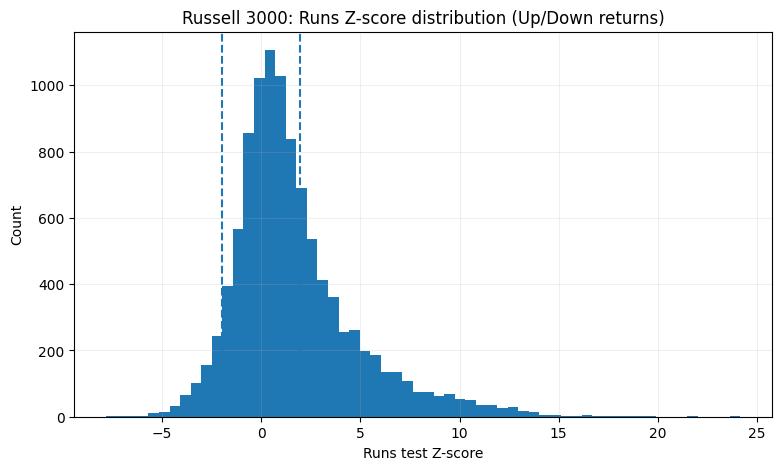

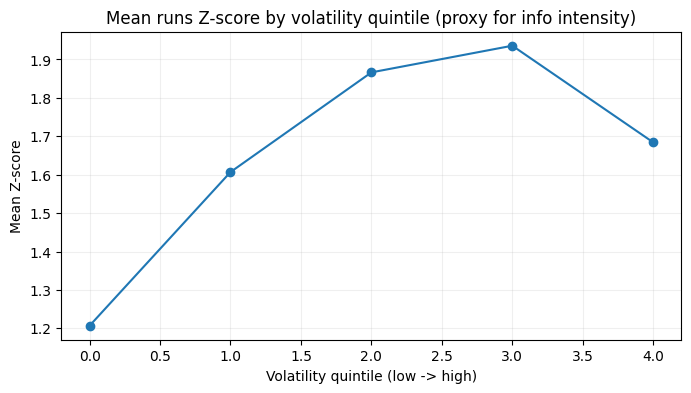

In [ ]:
df = r3000.dropna(subset=["z_runs"]).copy()

share_pos = (df["z_runs"] > 1.96).mean()
share_neg = (df["z_runs"] < -1.96).mean()

print(f"Share Z > +1.96 (more reversals than RW): {share_pos:.3f}")
print(f"Share Z < -1.96 (more persistence than RW): {share_neg:.3f}")
print("Mean Z:", df["z_runs"].mean(), "Median Z:", df["z_runs"].median())

plt.figure(figsize=(9,5))
plt.hist(df["z_runs"], bins=60)
plt.axvline( 1.96, linestyle="--")
plt.axvline(-1.96, linestyle="--")
plt.title("Russell 3000: Runs Z-score distribution (Up/Down returns)")
plt.xlabel("Runs test Z-score")
plt.ylabel("Count")
plt.grid(alpha=0.2)
plt.show()

df["vol_q"] = pd.qcut(df["volatility"], 5, labels=False, duplicates="drop")
grp = df.groupby("vol_q")["z_runs"].mean()

plt.figure(figsize=(8,4))
plt.plot(grp.index, grp.values, marker="o")
plt.title("Mean runs Z-score by volatility quintile (proxy for info intensity)")
plt.xlabel("Volatility quintile (low -> high)")
plt.ylabel("Mean Z-score")
plt.grid(alpha=0.2)
plt.show()
